In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch.optim as optim
import torch
from torch.utils.data import DataLoader, random_split
from transformers import CLIPProcessor
from tqdm import tqdm  # For a nice progress bar

# Add your source code directory to the Python path
import sys
import importlib
# Remove the cached module if it exists
if 'dataloader' in sys.modules:
    del sys.modules['dataloader']

if 'model' in sys.modules:
    del sys.modules['model']

project_path = '/content/drive/MyDrive/H-PeVL' # <-- MAKE SURE THIS IS YOUR FOLDER NAME
sys.path.append(f'{project_path}/src')

# Import your custom classes
from dataloader import FPHADataset
from model import BaselineModel

In [ ]:
import os

# 1. Define your source (Drive) and destination (Local)
# Make sure 'FPHA_dataset.zip' matches your actual zip filename on Drive
zip_path = '/content/drive/MyDrive/H-PeVL/data/First-Person Hand Action Benchmark (F-PHAB).zip'
local_extract_path = '/content/FPHA_Local'

# 2. Run the unzip logic
if not os.path.exists(local_extract_path):
    print("🚀 Copying zip from Drive to local runtime... (This speeds up training!)")
    # Copy to local disk first for faster/safer unzipping
    !cp "{zip_path}" /content/temp_dataset.zip

    print("📂 Unzipping dataset...")
    # Unzip quietly (-q) into the destination folder
    !unzip -q /content/temp_dataset.zip -d "{local_extract_path}"

    # Clean up to save disk space
    !rm /content/temp_dataset.zip
    print("✅ Unzipping complete! Data is ready in local runtime.")
else:
    print("✅ Dataset already found locally. Skipping unzip.")

🚀 Copying zip from Drive to local runtime... (This speeds up training!)
📂 Unzipping dataset...
✅ Unzipping complete! Data is ready in local runtime.


In [ ]:
import os
import glob

# 1. Set the path to where the Video_files are located
# This should match where you extracted the main zip
video_files_root = '/content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/Video_files'

print(f"📂 Looking for zipped subjects in: {video_files_root}")

# 2. Find all Subject_*.zip files
zip_files = glob.glob(os.path.join(video_files_root, "Subject_*.zip"))

if len(zip_files) > 0:
    print(f"Found {len(zip_files)} nested zip files. Extracting now...")

    for zip_file in zip_files:
        print(f"   - Unzipping {os.path.basename(zip_file)}...")
        # Unzip into the same directory
        !unzip -q "{zip_file}" -d "{video_files_root}"

        # Delete the zip file to save disk space (Critical in Colab!)
        os.remove(zip_file)

    print("✅ All subjects extracted and zip files cleaned up!")
else:
    print("No zip files found. They might already be extracted.")

# 3. Verify the structure
print("\nVerifying extraction...")
subject_folders = glob.glob(os.path.join(video_files_root, "Subject_*"))
print(f"Found {len(subject_folders)} subject folders: {[os.path.basename(f) for f in subject_folders]}")

📂 Looking for zipped subjects in: /content/FPHA_Local/First-Person Hand Action Benchmark (F-PHAB)/Video_files
Found 6 nested zip files. Extracting now...
   - Unzipping Subject_1.zip...
   - Unzipping Subject_6.zip...
   - Unzipping Subject_2.zip...
   - Unzipping Subject_3.zip...
   - Unzipping Subject_4.zip...
   - Unzipping Subject_5.zip...
✅ All subjects extracted and zip files cleaned up!

Verifying extraction...
Found 6 subject folders: ['Subject_2', 'Subject_1', 'Subject_6', 'Subject_3', 'Subject_5', 'Subject_4']


In [ ]:
# ==================================
# Cell 2: Configuration
# ==================================
class Config:
    DATA_ROOT = f'/content/drive/MyDrive/H-PeVL/data/First-Person Hand Action Benchmark (F-PHAB)' # <-- VERIFY THIS PATH
    CHECKPOINT_PATH = f'{project_path}/checkpoints'
    BATCH_SIZE = 16  # Adjust based on GPU memory (16 should be fine for a T4)
    NUM_EPOCHS = 10
    LEARNING_RATE = 5e-6
    NUM_FRAMES = 16
    TRAIN_VAL_SPLIT = 0.8 # 80% for training, 20% for validation

config = Config()

# Ensure the checkpoint directory exists
import os
os.makedirs(config.CHECKPOINT_PATH, exist_ok=True)

In [ ]:
# ==================================
# Cell 3: Load Data and Create Splits (Fixed Collate Function)
# ==================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

# --- Fixed Collate Function ---
def collate_fn(batch):
    # Stack images
    pixel_values = torch.stack([item["pixel_values"] for item in batch])

    # Collect raw text strings
    raw_texts = [item["text"] for item in batch]

    # Tokenize text for training
    inputs = processor(
        text=raw_texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    batch_dict = {
        "pixel_values": pixel_values,
        "input_ids": inputs["input_ids"],
        "attention_mask": inputs["attention_mask"],
        "text": raw_texts # <--- CRITICAL ADDITION: Return the raw text list
    }

    # If using pose, handle it (for future compatibility)
    if "pose_values" in batch[0]:
        pose_values = torch.stack([item["pose_values"] for item in batch])
        batch_dict["pose_values"] = pose_values

    return batch_dict

# Instantiate your full dataset
full_dataset = FPHADataset(
    data_root=config.DATA_ROOT,
    processor=processor,
    num_frames=config.NUM_FRAMES
)

# Split the dataset
train_size = int(config.TRAIN_VAL_SPLIT * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create DataLoaders with the fixed collate_fn
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Full dataset size: {len(full_dataset)}")
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Using device: cuda
Loaded 185 samples from /content/drive/MyDrive/H-PeVL/data/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_1_info.txt
Loaded 185 samples from /content/drive/MyDrive/H-PeVL/data/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_2_info.txt
Loaded 190 samples from /content/drive/MyDrive/H-PeVL/data/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_3_info.txt
Loaded 204 samples from /content/drive/MyDrive/H-PeVL/data/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_4_info.txt
Loaded 208 samples from /content/drive/MyDrive/H-PeVL/data/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_5_info.txt
Loaded 206 samples from /content/drive/MyDrive/H-PeVL/data/First-Person Hand Action Benchmark (F-PHAB)/Subjects_info/Subject_6_info.txt
Full dataset size: 1024
Training set size: 819
Validation set size: 205


In [ ]:
# ==================================
# Cell 4: Initialize Model, Loss, and Optimizer
# ==================================
import torch.nn as nn


model = BaselineModel().to(device)

# Verify which parameters are trainable
model.get_trainable_params()

# This is a standard contrastive loss implementation
def contrastive_loss(video_features, text_features, logit_scale):
    # Normalize features to have unit length
    video_features = video_features / video_features.norm(dim=-1, keepdim=True)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    # Calculate cosine similarity
    logits = (text_features @ video_features.T) * logit_scale

    # Create ground-truth labels (diagonal alignment)
    labels = torch.arange(len(logits)).to(device)

    # Calculate symmetric cross-entropy loss
    loss_text = nn.CrossEntropyLoss()(logits, labels)
    loss_video = nn.CrossEntropyLoss()(logits.T, labels)

    return (loss_text + loss_video) / 2

# Pass only the trainable parameters (adapters) to the optimizer
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=config.LEARNING_RATE)

✓ CLIP parameters frozen
✓ Adapter layers initialized (dim=256)
Trainable parameters: 790,784
Total parameters: 150,411,521
Percentage trainable: 0.53%


In [ ]:
# ==================================
# Cell 5: Training & Validation Loop (With Metrics Logging)
# ==================================
import os
import json

# Define paths
latest_checkpoint_path = f"{config.CHECKPOINT_PATH}/baseline_latest_checkpoint.pth"
best_model_path = f"{config.CHECKPOINT_PATH}/baseline_best_model.pth"
history_path = f"{config.CHECKPOINT_PATH}/training_history.json"

# --- RESUME LOGIC ---
start_epoch = 0
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []} # Initialize history

if os.path.exists(latest_checkpoint_path):
    print(f"🔄 Found checkpoint at {latest_checkpoint_path}. Loading...")
    checkpoint = torch.load(latest_checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']

    # Load history if available
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history = json.load(f)

    print(f"✅ Resuming training from Epoch {start_epoch + 1}")
else:
    print("ℹ️ No checkpoint found. Starting training from scratch.")

# --- MAIN LOOP ---
for epoch in range(start_epoch, config.NUM_EPOCHS):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.NUM_EPOCHS} [Train]")

    for batch in progress_bar:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        video_features, text_features = model(pixel_values, input_ids, attention_mask)

        logit_scale = model.clip.logit_scale.exp()
        loss = contrastive_loss(video_features, text_features, logit_scale)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    progress_bar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{config.NUM_EPOCHS} [Val]")

    with torch.no_grad():
        for batch in progress_bar_val:
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            video_features, text_features = model(pixel_values, input_ids, attention_mask)

            logit_scale = model.clip.logit_scale.exp()
            loss = contrastive_loss(video_features, text_features, logit_scale)

            val_loss += loss.item()
            progress_bar_val.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1} finished. Avg Train Loss: {avg_train_loss:.4f}, Avg Val Loss: {avg_val_loss:.4f}")

    # --- UPDATE HISTORY ---
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    # Save history to file (so you can plot it later even if Colab crashes)
    with open(history_path, 'w') as f:
        json.dump(history, f)

    # --- CHECKPOINTING ---
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_loss': best_val_loss,
    }, latest_checkpoint_path)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"✓ New best model saved with validation loss: {best_val_loss:.4f}")

ℹ️ No checkpoint found. Starting training from scratch.


Epoch 1/10 [Val]: 100%|██████████| 15/15 [02:18<00:00,  9.24s/it, loss=2.43]


Epoch 1 finished. Avg Train Loss: 3.4099, Avg Val Loss: 2.7678
✓ New best model saved with validation loss: 2.7678


Epoch 2/10 [Val]: 100%|██████████| 15/15 [02:20<00:00,  9.38s/it, loss=2.24]


Epoch 2 finished. Avg Train Loss: 3.1273, Avg Val Loss: 2.5676
✓ New best model saved with validation loss: 2.5676


...

Epoch 7/10 [Val]: 100%|██████████| 15/15 [02:25<00:00,  9.68s/it, loss=1.57]


Epoch 7 finished. Avg Train Loss: 2.3289, Avg Val Loss: 1.9299
✓ New best model saved with validation loss: 1.9299


Epoch 8/10 [Val]: 100%|██████████| 15/15 [02:25<00:00,  9.70s/it, loss=1.45]


Epoch 8 finished. Avg Train Loss: 2.1957, Avg Val Loss: 1.8209
✓ New best model saved with validation loss: 1.8209


Epoch 9/10 [Train]:  49%|████▉     | 29/59 [04:46<04:57,  9.92s/it, loss=2.05]

Loading best model for evaluation...
✓ CLIP parameters frozen
✓ Adapter layers initialized (dim=256)


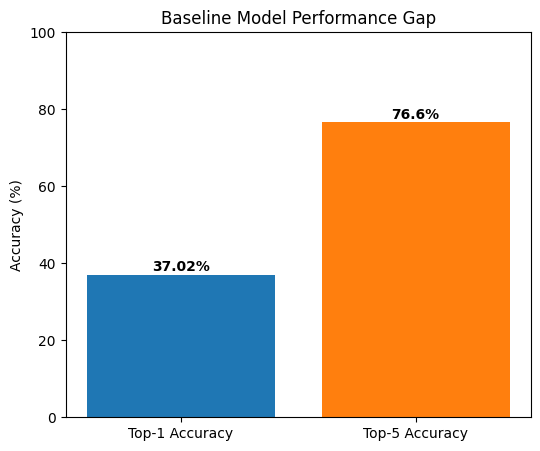

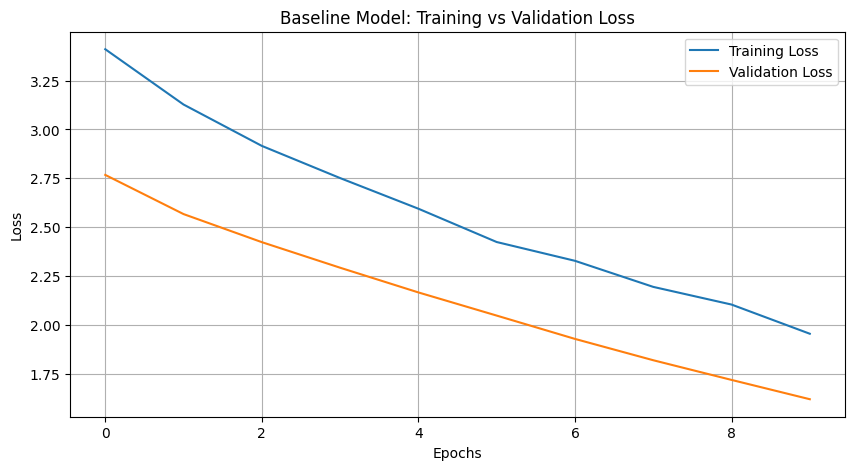

Preparing global classification evaluation...
Encoded 45 class labels.
Running inference on validation set...


Evaluating:   8%|▊         | 1/13 [00:11<02:13, 11.10s/it]

In [ ]:
# ==================================
# Cell 6: Final Evaluation & Visualization (Fixed)
# ==================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import json
import torch.nn.functional as F
import numpy as np

# 1. Load the Best Model
print("Loading best model for evaluation...")
model = BaselineModel().to(device)
model.load_state_dict(torch.load(best_model_path))
model.eval()

# 2. Load History for Loss Curves
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)

    # --- FIGURE 1: Loss Curves ---
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Baseline Model: Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# 3. Setup for Global Evaluation (1 vs 45 classes)
print("Preparing global classification evaluation...")

# Define all 45 actions (from your dataset info)
all_actions = [
    'charge_cell_phone', 'clean_glasses', 'close_juice_bottle', 'close_liquid_soap', 'close_milk',
    'close_peanut_butter', 'drink_mug', 'flip_pages', 'flip_sponge', 'give_card', 'give_coin',
    'handshake', 'high_five', 'light_candle', 'open_juice_bottle', 'open_letter', 'open_liquid_soap',
    'open_milk', 'open_peanut_butter', 'open_soda_can', 'open_wallet', 'pour_juice_bottle',
    'pour_liquid_soap', 'pour_milk', 'pour_wine', 'prick', 'put_salt', 'put_sugar', 'put_tea_bag',
    'read_letter', 'receive_coin', 'scoop_spoon', 'scratch_sponge', 'sprinkle', 'squeeze_paper',
    'squeeze_sponge', 'stir', 'take_letter_from_enveloppe', 'tear_paper', 'toast_wine', 'unfold_glasses',
    'use_calculator', 'use_flash', 'wash_sponge', 'write'
]
# Create mapping for confusion matrix
action_to_idx = {action: i for i, action in enumerate(all_actions)}

# Pre-encode all 45 text descriptions
text_prompts = [f"a video of a hand performing the action of {action}" for action in all_actions]
text_inputs = processor(text=text_prompts, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    # Encode text using CLIP
    class_embeddings = model.clip.get_text_features(**text_inputs)
    # Apply the trained text adapter
    class_embeddings = model.text_adapter(class_embeddings)
    # Normalize
    class_embeddings /= class_embeddings.norm(dim=-1, keepdim=True)

print(f"Encoded {len(all_actions)} class labels.")

# 4. Run Inference on Validation Set
all_preds = []
all_targets = []

print("Running inference on validation set...")
eval_loader = val_loader

with torch.no_grad():
    for batch in tqdm(eval_loader, desc="Evaluating"):
        pixel_values = batch["pixel_values"].to(device)
        # Get the actual text labels for this batch to find ground truth indices
        batch_texts = batch["text"] # This relies on your updated dataloader returning raw text in 'text' key

        # 1. Get Video Features
        # Manual forward pass to access features before they are lost
        batch_size, num_frames, c, h, w = pixel_values.shape
        pixel_values = pixel_values.view(batch_size * num_frames, c, h, w)

        # Encode frames
        frame_features = model.clip.get_image_features(pixel_values)
        frame_features = frame_features.view(batch_size, num_frames, -1)

        # Apply adapters (Temporal -> Mean -> Video Adapter)
        frame_features = model.temporal_adapter(frame_features)
        video_features = frame_features.mean(dim=1)
        video_features = model.video_adapter(video_features)

        # Normalize
        video_features /= video_features.norm(dim=-1, keepdim=True)

        # 2. Calculate Similarity (Video vs All 45 Classes)
        # (Batch, 512) @ (512, 45) -> (Batch, 45)
        logit_scale = model.clip.logit_scale.exp()
        logits = (logit_scale * video_features @ class_embeddings.T)

        all_preds.append(logits.cpu())

        # 3. Determine Ground Truth Indices
        # Extract the action name from the full prompt "a video... of {action}"
        # Or use the fact that your dataloader constructs prompts consistently
        batch_indices = []
        for t in batch_texts:
            # The prompt is "a video ... of {label}"
            # We simply look for which action string is in the text
            found = False
            for action in all_actions:
                if action in t:
                    batch_indices.append(action_to_idx[action])
                    found = True
                    break
            if not found:
                batch_indices.append(0) # Fallback (should not happen)

        all_targets.append(torch.tensor(batch_indices))

# Concatenate
all_logits = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

# 5. Calculate Metrics
def accuracy(output, target, topk=(1,)):
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)
        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res.append(correct_k.mul_(100.0 / batch_size))
        return res

acc1, acc5 = accuracy(all_logits, all_targets, topk=(1, 5))

print(f"\n=== Final Baseline Results ===")
print(f"Top-1 Accuracy: {acc1.item():.2f}%")
print(f"Top-5 Accuracy: {acc5.item():.2f}%")

# --- FIGURE 2: Confusion Matrix ---
# Get top-1 predictions
_, top_preds = all_logits.topk(1, 1, True, True)
top_preds = top_preds.squeeze().numpy()
targets_np = all_targets.numpy()

cm = confusion_matrix(targets_np, top_preds)
plt.figure(figsize=(20, 16)) # Large figure for 45 classes
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=all_actions, yticklabels=all_actions)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Add this to your evaluation cell
accuracies = [37.02, 76.60]
labels = ['Top-1 Accuracy', 'Top-5 Accuracy']

plt.figure(figsize=(6, 5))
plt.bar(labels, accuracies, color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Accuracy (%)')
plt.title('Baseline Model Performance Gap')
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v}%", ha='center', fontweight='bold')
plt.show()